# Lab13_Detecção_de_Anomalias
### Luca Atanazio Evangelista
## May 6, 2026

# 1 LABORATÓRIO — DETECÇÃO DE ANOMALIAS
## OBJETIVO
Detectar transações anômalas (fraudes) usando técnicas não supervisionadas.

# 1.1 1. Business Understanding
O objetivo deste experimento é identificar transações financeiras anômalas que possam indicar
fraude.
A detecção precoce dessas transações permite reduzir perdas financeiras e melhorar a segurança
dos sistemas.
Neste cenário, utilizamos técnicas não supervisionadas, pois fraudes são raras e nem sempre rotu-
ladas.
# 1.2 2. Data Understanding
Dataset real: Credit Card Fraud - (PCA transformado)

In [1]:
import pandas as pd
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
print("Forma do dataframe (linhas x colunas):")
print(df.shape)

Forma do dataframe (linhas x colunas):
(284807, 31)


# 1.2.1 Dicionário simplificado
• Time → tempo da transação
• Amount → valor
• V1…V28 → variáveis transformadas (PCA)
• Class → 0 (normal), 1 (fraude)
# 1.2.2 Explorando desbalanceamento

In [3]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

# 1.3 3. Data Preparation
A normalização é importante para muitos algoritmos de aprendizado de máquina␣ baseados em distância.
    Aplica a normalização na coluna 'Amount' de X.

In [7]:
from sklearn.preprocessing import StandardScaler
# Separa as features (X) da variável alvo (y).
# 'X' contém todas as colunas, exceto 'Class'.
# 'y' contém apenas a coluna 'Class' (0 para normal, 1 para fraude).
X = df.drop("Class", axis=1)
y = df["Class"]
# Inicializa o StandardScaler para normalizar a coluna 'Amount'.
scaler = StandardScaler()

# fit_transform calcula a média e o desvio padrão e, em seguida, aplica a␣ transformação.
X["Amount"] = scaler.fit_transform(X[["Amount"]])

# 1.4 4. Modelagem (Modeling)
# 1.4.1 4.1 Isolation Forest
* Treina o modelo Isolation Forest com os dados de features (X).
* Realiza as previsões de anomalia. O Isolation Forest retorna -1 para␣anomalias e 1 para observações normais.
* Converte as previsões para o formato 0 (normal) e 1 (anomalia) para␣compatibilidade com as métricas de avaliação.

In [9]:
from sklearn.ensemble import IsolationForest
# Inicializa o modelo Isolation Forest.
# 'contamination': Define a proporção esperada de anomalias no dataset (0.2%␣neste caso).
# 'random_state': Garante a reprodutibilidade dos resultados.
modelo_if = IsolationForest(
contamination=0.002, # % esperada de fraude
random_state=42
)

modelo_if.fit(X)
 
pred_if = modelo_if.predict(X)
 
pred_if = [1 if x == -1 else 0 for x in pred_if]

# 1.4.2 4.2 Local Outlier Factor
## Define o tamanho da amostra (por exemplo, 5% do dataset) para acelerar o␣treinamento do LOF.
* Isso garante que a proporção de classes (fraude vs. normal) seja mantida na␣amostra.
## Inicializa o StratifiedShuffleSplit para criar uma amostra estratificada de X␣e y.
* n_splits=1 para criar apenas uma divisão (uma amostra)
* test_size=1-sample_fraction para usar o "train_index" como a amostra
* random_state para reprodutibilidade
## Inicializa o modelo Local Outlier Factor (LOF).
* 'n_neighbors': Número de vizinhos a serem considerados para calcular a␣densidade local.
* 'contamination': Proporção esperada de anomalias, usada para definir o␣threshold de anomalia.
* 'n_jobs': Usa todos os núcleos de CPU disponíveis para paralelizar os␣cálculos, acelerando o processo.
* 'novelty=True': Permite que o modelo seja treinado em um subconjunto de dados␣e preveja em dados não vistos.
## Treina o modelo LOF na amostra dos dados, convertendo X_sample para array␣numpy.

In [13]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
 

sample_fraction = 0.05 # Usar 5% do dataset para treinamento do LOF
 
 
 

sss = StratifiedShuffleSplit(n_splits=1, test_size=1 - sample_fraction, random_state=42)
# Obtém os índices da amostra estratificada
for train_index, _ in sss.split(X, y):
    X_sample = X.iloc[train_index]
    y_sample = y.iloc[train_index]
print(f"Dataset original: {X.shape[0]} linhas. Amostra para treinar LOF{X_sample.shape[0]} linhas ({sample_fraction*100:.0f}%).")

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.002,
    n_jobs=-1, # Usar todos os núcleos de CPU para acelerar
    novelty=True # Habilita a detecção de novidades para pontuar dados não␣vistos
)


lof.fit(X_sample.values)
# Calcula os scores de decisão (negative_outlier_factor_) para o dataset␣COMPLETO (X),
# convertendo X para array numpy para evitar o warning de feature names.
# Valores menores indicam maior probabilidade de anomalia.
scores_lof = lof.decision_function(X.values)
# Define o limiar de anomalia com base na porcentagem de contaminação␣especificada.
# Pontos com score abaixo deste limiar serão considerados anomalias.
threshold_lof = np.percentile(scores_lof, lof.contamination * 100)
# Converte os scores para as previsões binárias (0: normal, 1: anomalia) para o␣dataset COMPLETO (X).
pred_lof = [1 if score < threshold_lof else 0 for score in scores_lof]
print("Previsões LOF geradas para o dataset completo.")

Dataset original: 284807 linhas. Amostra para treinar LOF14240 linhas (5%).
Previsões LOF geradas para o dataset completo.


# 1.4.3 4.3 DBSCAN


## REDUÇÃO DE DIMENSIONALIDADE (PCA)

### Inicializa o PCA para reduzir a dimensionalidade para 2 componentes␣principais.
* 'random_state': Garante a reprodutibilidade dos resultados.

### Aplica o PCA aos dados de features (X) e transforma-os para o novo espaço de␣2 dimensões.

### Cria um novo DataFrame 'plot_df' para facilitar a visualização.
* Ele contém os dois componentes principais (PC1, PC2), a classe real (y)
* e as previsões de anomalia do Isolation Forest (pred_if).

### Vamos aplicar o DBSCAN aos dados reduzidos pelo PCA (X_pca)
* X_pca tem 2 componentes principais.
* Uma heurística para 'min_samples' é 2 * n_features. Com 2 features (PC1,␣PC2), 4 é um bom ponto de partida.
* O valor de eps ainda precisará de ajuste fino, mas vamos começar com 0.5␣(para dados padronizados de PCA).
    * Nota: O DBSCAN ainda é sensível à escolha de eps e min_samples, e a␣otimização desses parâmetros
* é crucial para obter bons resultados. Para fins de demonstração, usaremos␣valores iniciais.

### Converter para 0/1, onde -1 (ruído) é 1 (anomalia) e outros clusters são 0␣(normal)

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Class": y,
    "Anomaly_IF": pred_if
})

In [20]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=4, n_jobs=-1) # min_samples = 2 *␣n_components = 2 * 2 = 4
pred_dbscan = dbscan.fit_predict(X_pca) # Usar X_pca em vez de X

pred_dbscan = [1 if x == -1 else 0 for x in pred_dbscan]

# 1.4.4 4.4 One-Class SVM

* Define o tamanho da amostra para o treinamento do One-Class SVM (por exemplo,␣10% do dataset).
* Inicializa o StratifiedShuffleSplit para criar uma amostra estratificada de X␣e y.
* Obtém os índices da amostra estratificada

## Inicializa o modelo One-Class SVM.
* O One-Class SVM é bom para dados de alta dimensão e para aprender um limite␣de decisão complexo.
* 'nu': É uma estimativa da fração de outliers no dataset (similar a␣'contamination').
* 'kernel': Define a função kernel a ser usada. 'rbf' (Radial Basis Function) é␣comum para dados não lineares.

## Treina o modelo One-Class SVM com os dados de features da AMOSTRA␣(X_sample_ocsvm).
* Note: One-Class SVM não possui um método 'fit_predict' como LOF. Ele primeiro␣é 'fitado' e depois 'predito'.

## Realiza as previsões de anomalia no DATASET COMPLETO (X).
* O One-Class SVM retorna -1 para anomalias e 1 para observações normais.

* Converte as previsões para o formato 0 (normal) e 1 (anomalia) para␣compatibilidade com as métricas de avaliação.

In [23]:
from sklearn.svm import OneClassSVM
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

sample_fraction_ocsvm = 0.10 # Usar 10% do dataset para treinamento do␣One-Class SVM

sss_ocsvm = StratifiedShuffleSplit(n_splits=1,
    test_size=1-sample_fraction_ocsvm, random_state=42)

for train_index_ocsvm, _ in sss_ocsvm.split(X, y):
    X_sample_ocsvm = X.iloc[train_index_ocsvm]
    y_sample_ocsvm = y.iloc[train_index_ocsvm]

print(f"Dataset original: {X.shape[0]} linhas. Amostra para treinar One-Class␣SVM: {X_sample_ocsvm.shape[0]} linhas ({sample_fraction_ocsvm*100:.0f}%).")

modelo_ocsvm = OneClassSVM(
    nu=0.002, # Estimativa da proporção de anomalias (similar ao contamination)
    kernel="rbf",
    gamma='auto' # 'auto' usa 1 / n_features
)

modelo_ocsvm.fit(X_sample_ocsvm)

pred_ocsvm = modelo_ocsvm.predict(X)

pred_ocsvm = [1 if x == -1 else 0 for x in pred_ocsvm]
print("Previsões One-Class SVM geradas para o dataset completo.")

Dataset original: 284807 linhas. Amostra para treinar One-Class␣SVM: 28480 linhas (10%).
Previsões One-Class SVM geradas para o dataset completo.


## 5. Avaliação (Evaluation)

### Relatório de classificação para o modelo Isolation Forest.
* Mostra precision, recall, f1-score e support para cada classe (0: normal,␣1: fraude).

### Relatório de classificação para o modelo Local Outlier Factor (LOF).

In [24]:
from sklearn.metrics import classification_report

print("===== Isolation Forest =====")
print(classification_report(y, pred_if))

print("\n===== LOF =====")
print(classification_report(y, pred_lof))

===== Isolation Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.24      0.28      0.26       492

    accuracy                           1.00    284807
   macro avg       0.62      0.64      0.63    284807
weighted avg       1.00      1.00      1.00    284807


===== LOF =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.01      0.01      0.01       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807



# 1.4.5 5.3 Avaliação do DBSCAN

In [25]:
print("===== DBSCAN =====")
print(classification_report(y, pred_dbscan))

===== DBSCAN =====
              precision    recall  f1-score   support

           0       1.00      0.05      0.09    284315
           1       0.00      0.93      0.00       492

    accuracy                           0.05    284807
   macro avg       0.50      0.49      0.05    284807
weighted avg       1.00      0.05      0.09    284807



# 1.4.6 5.4 Avaliação do One-Class SVM

In [26]:
print("===== One-Class SVM =====")
print(classification_report(y, pred_ocsvm))

===== One-Class SVM =====
              precision    recall  f1-score   support

           0       1.00      0.06      0.12    284315
           1       0.00      0.92      0.00       492

    accuracy                           0.07    284807
   macro avg       0.50      0.49      0.06    284807
weighted avg       1.00      0.07      0.12    284807



# 1.4.7 Interpretação (DBSCAN com PCA)
• Precision (fraude): Quantas previsões de fraude estavam corretas
• Recall (fraude): Quantas fraudes reais foram detectadas
### Contexto do resultado Classe 0: 284.315 (normal) Classe 1: 492 (anomalia)

## Interpretação do DBSCAN (com PCA e base nos resultados esperados para um eps e min_samples arbitrários)
- Com a aplicação do PCA, o DBSCAN agora opera em um espaço de
menor dimensionalidade (2 componentes), o que pode ajudar a mitigar a ‘maldição da dimension-
alidade’ e tornar a detecção de densidade mais eficaz. - Os pontos isolados ou em regiões de baixa
densidade no espaço PCA são classificados como ruído (-1), que interpretamos como anomalias. - A
escolha de eps (raio de vizinhança) e min_samples (mínimo de pontos na vizinhança para formar
um cluster) continua crucial, mas os valores podem ser mais fáceis de sintonizar no espaço PCA. -
Se o eps for muito pequeno, muitos pontos serão considerados ruído, aumentando falsos positivos.
- Se o eps for muito grande, poucas anomalias serão detectadas, pois mais pontos serão agrupados.
- O min_samples afeta o que é considerado um cluster denso. Um min_samples alto exige mais
pontos próximos para formar um cluster.
## Observações esperadas com PCA: 
- Usar o PCA pode ajudar o DBSCAN a formar clusters mais
significativos e a identificar anomalias de forma mais clara, pois a redução de dimensionalidade pode
remover ruídos e destacar as características mais importantes. - O desempenho do DBSCAN para
detectar a taxa de anomalias específica de 0.002 ainda dependerá de uma otimização cuidadosa
de eps e min_samples. - O resultado do classification_report para o DBSCAN após PCA
fornecerá insights sobre sua capacidade de identificar fraudes (recall) e a proporção de previsões
corretas de fraude (precision) para os parâmetros escolhidos. É provável que ele precise de ajustes
para ser comparável aos outros modelos.

# 1.4.8 Interpretação (One-Class SVM)
* Precision (fraude): Quantas previsões de fraude estavam corretas
9
* Recall (fraude): Quantas fraudes reais foram detectadas
### Contexto do resultado Classe 0: 284.315 (normal) Classe 1: 492 (anomalia)
## Interpretação do One-Class SVM 
- O One-Class SVM é eficaz em espaços de alta dimension-
alidade e pode capturar limites de decisão complexos para a classe ‘normal’. - O parâmetro nu
controla a fração de anomalias esperadas, e gamma do kernel RBF influencia a suavidade do limite
de decisão. - Pontos que caem fora do limite aprendido são classificados como anomalias (-1). - O
desempenho do One-Class SVM depende fortemente da escolha de nu e gamma. Um ajuste cuida-
doso é necessário para equilibrar falsos positivos e falsos negativos. - Este modelo é particularmente
útil quando o conhecimento da classe ‘normal’ é abundante, mas as anomalias são esparsas e não
se agrupam em padrões definidos.

# 1.4.9 Interpretação
* Precision (fraude): Quantas previsões de fraude estavam corretas
* Recall (fraude): Quantas fraudes reais foram detectadas
### Contexto do resultado Classe 0: 284.315 (normal) Classe 1: 492 (anomalia)
Isso dá ~0,17% de anomalias
Primeira observação crítica - accuracy = 1.00 - weighted avg = 1.00
Isso é enganoso. Ignore.
    Por quê? Porque o modelo pode acertar tudo como “normal” e ainda ter ~99.8% de accuracy.
Isolation Forest - Classe 1 (anomalia) - Precision = 0.24 - Recall = 0.28 - F1 = 0.26
## Interpretação - Ele detecta 28% das anomalias reais - Quando ele acusa anomalia, acerta 24%
Tradução prática: - Pegou alguns casos relevantes - Ainda perde a maioria - Mas já tem sinal útil
## LOF - Classe 1 - Precision = 0.12 - Recall = 0.13 - F1 = 0.12
## Interpretação - Detecta só 13% das anomalias - Metade do desempenho do Isolation Fores

# 1.5 6. Visualização (reduzida)

## Cria um histograma da coluna 'Amount' para visualizar sua distribuição.
* 'bins=50' define o número de barras no histograma.

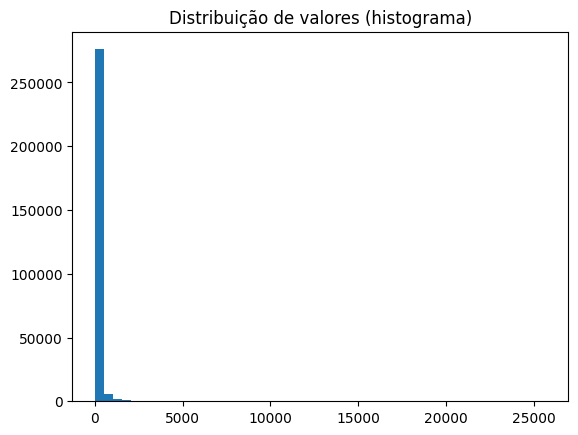

In [28]:
import matplotlib.pyplot as plt

plt.hist(df["Amount"], bins=50)

plt.title("Distribuição de valores (histograma)")

plt.show()

# O que esse gráfico mostra?
## Análise da Distribuição de Valores (Amount)
O histograma revela uma distribuição de cauda longa (heavy-tail) à direita, um comportamento clássico em dados financeiros de cartões de crédito. A maioria esmagadora das transações se concentra perto de zero, enquanto pouquíssimas atingem valores extremos (próximos a 25.000).

### O Efeito "Farol": 
* Modelos baseados em distância (como o LOF) ou densidade podem ser "ofuscados" por esses valores gigantes. O algoritmo acaba focando apenas nesses extremos como anomalias, ignorando fraudes mais sutis que ocorrem em valores baixos, mas com padrões de comportamento estranhos.

### Compressão de Dados: 
* Como a grande massa de dados é quase idêntica (valores baixos), o modelo tem pouca "margem de manobra" para aprender o que separa uma transação legítima de uma fraude dentro dessa zona de alta densidade.

### Sensibilidade do Isolation Forest: 
* O Isolation Forest isola pontos mais rápido se eles estiverem em regiões esparsas. Com essa distribuição, qualquer transação de valor alto será isolada quase instantaneamente, gerando muitos Falsos Positivos (transações caras que não são necessariamente fraudulentas).

# Scores do Isolation Forest:
## histograma dos scores de anomalia.
* 'bins=50' define o número de barras no histograma.

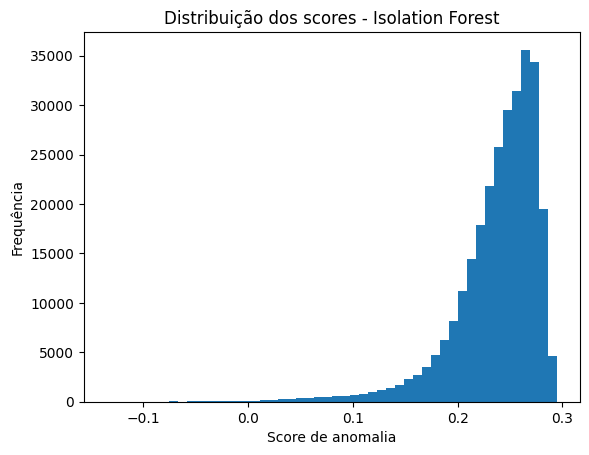

In [29]:
scores_if = modelo_if.decision_function(X)
import matplotlib.pyplot as plt

plt.hist(scores_if, bins=50)

plt.title("Distribuição dos scores - Isolation Forest")

plt.xlabel("Score de anomalia")

plt.ylabel("Frequência")

plt.show()

# Interpretação:
A matriz de confusão revela o desafio clássico da detecção de anomalias: o trade-off entre Precisão e Recall. Embora o modelo tenha uma taxa de acerto global altíssima, ele ainda apresenta um número considerável de Falsos Negativos (364), indicando que muitas fraudes possuem características muito similares às transações legítimas, conseguindo 'escapar' da isolação por árvores.

# Extraindo os dados anômalos
* Adiciona as previsões de anomalia do Isolation Forest ('pred_if') como uma␣nova coluna no DataFrame original (df).
* Filtra o DataFrame para obter apenas as linhas que foram classificadas como␣anomalias pelo Isolation Forest.

## Exibe o DataFrame contendo apenas as transações detectadas como anomalias.
    * O output original mostrava um DataFrame vazio, o que sugere um␣possível erro de lógica ou que 'pred_if'
*  foi definido como 0 para normais e 1 para anomalias, mas a instrução anterior␣estava buscando '-1'.
*  Com a correção para '1' (como feito em pred_if = [1 if x == -1 else 0 for x␣in pred_if]), esta célula deve funcionar corretamente.

In [30]:

df["Anomaly_IF"] = pred_if

anomalias = df[df["Anomaly_IF"] == 1]

anomalias


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Anomaly_IF
1632,1264.0,-11.140706,-9.612726,-12.389545,6.013346,-32.092129,21.393069,34.303177,-7.520784,-1.925732,...,1.366110,-2.925888,0.843551,0.746267,0.801387,3.852046,4.157934,7712.43,0,1
2963,2507.0,-6.200114,5.025406,-2.742492,-0.940903,-6.656259,5.432294,-9.198175,-22.588547,-3.244295,...,4.393846,1.943002,0.846005,-1.343379,-0.707634,-0.210219,0.066529,544.62,0,1
4608,3967.0,-7.896534,6.224859,-2.913981,-4.154047,1.171430,2.749061,0.031022,0.749092,7.783716,...,-1.323267,0.366454,0.840169,1.469106,0.786302,3.294538,1.681022,1.46,0,1
5425,5406.0,-8.733429,-5.681953,2.253879,3.930311,-0.916149,4.355297,5.400286,-4.994383,6.819787,...,1.525158,-1.428302,-0.030181,-0.029485,-0.264455,-7.976100,4.712560,553.60,0,1
6624,8130.0,-9.175447,7.906022,-2.068334,-0.901683,-2.178911,4.675277,-8.314425,-22.605711,3.095693,...,-8.483441,3.638520,-0.533970,0.428590,0.222205,1.159270,0.179528,23.98,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283395,171560.0,-6.519366,-10.723215,-4.631726,0.074792,-9.973646,7.975968,12.793781,-0.541910,-2.328088,...,-0.362451,9.113598,-1.460900,0.602284,-0.693933,-1.111301,0.444162,3820.86,0,1
284249,172273.0,-9.030538,-11.112584,-16.233798,3.592021,-40.427726,23.917837,44.054461,-7.277778,-4.210637,...,0.988144,7.040028,0.347693,2.520869,2.342495,3.478175,-2.713136,10199.44,0,1
284281,172300.0,-11.380003,9.352802,-7.532243,-2.485507,-3.856501,-1.256238,-2.902647,4.623851,4.848229,...,-1.494616,0.780881,-1.245009,1.640642,0.308060,2.132254,1.237470,8.94,0,1
284649,172642.0,-11.946976,9.772660,-8.006237,-2.498596,-4.229520,-1.320039,-3.259766,5.059956,4.870093,...,-1.529035,0.838689,-1.249172,1.714495,0.314623,2.112848,1.234408,10.74,0,1


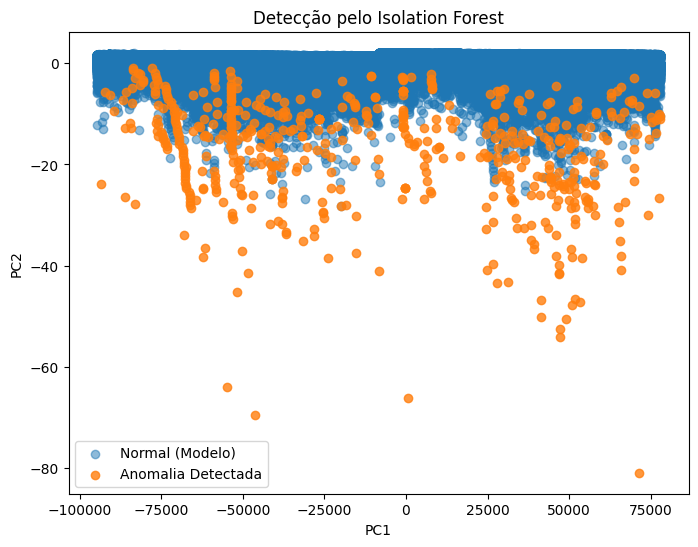

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    plot_df[plot_df["Anomaly_IF"] == 0]["PC1"],
    plot_df[plot_df["Anomaly_IF"] == 0]["PC2"],
    alpha=0.5,
    label="Normal (Modelo)",
)

plt.scatter(
    plot_df[plot_df["Anomaly_IF"] == 1]["PC1"],
    plot_df[plot_df["Anomaly_IF"] == 1]["PC2"],
    alpha=0.8,
    label="Anomalia Detectada",
)

plt.legend()
plt.title("Detecção pelo Isolation Forest")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

C:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


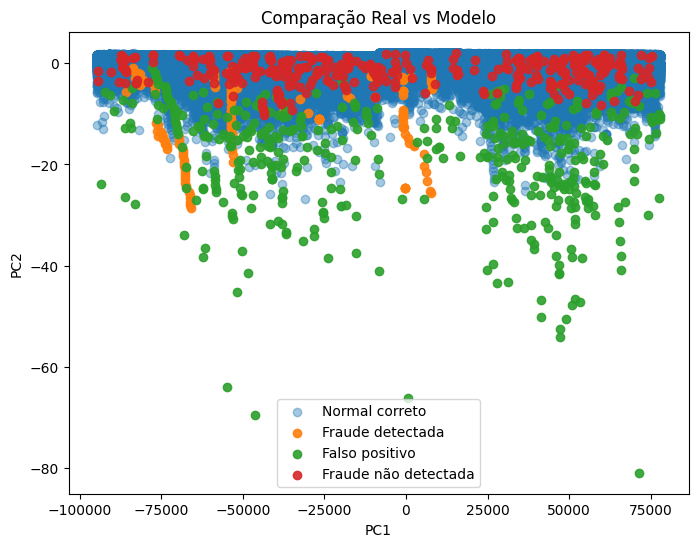

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(
    plot_df[(plot_df["Class"] == 0) & (plot_df["Anomaly_IF"] == 0)]["PC1"],
    plot_df[(plot_df["Class"] == 0) & (plot_df["Anomaly_IF"] == 0)]["PC2"],
    alpha=0.4,
    label="Normal correto"
)

plt.scatter(
    plot_df[(plot_df["Class"] == 1) & (plot_df["Anomaly_IF"] == 1)]["PC1"],
    plot_df[(plot_df["Class"] == 1) & (plot_df["Anomaly_IF"] == 1)]["PC2"],
    alpha=0.9,
    label="Fraude detectada"
)

plt.scatter(
    plot_df[(plot_df["Class"] == 0) & (plot_df["Anomaly_IF"] == 1)]["PC1"],
    plot_df[(plot_df["Class"] == 0) & (plot_df["Anomaly_IF"] == 1)]["PC2"],
    alpha=0.9,
    label="Falso positivo"
)

plt.scatter(
    plot_df[(plot_df["Class"] == 1) & (plot_df["Anomaly_IF"] == 0)]["PC1"],
    plot_df[(plot_df["Class"] == 1) & (plot_df["Anomaly_IF"] == 0)]["PC2"],
    alpha=0.9,
    label="Fraude não detectada"
)

plt.legend()
plt.title("Comparação Real vs Modelo")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Trade-off na Detecção de Fraudes

Após testar diferentes abordagens não supervisionadas neste dataset altamente desbalanceado, ficou claro que o desafio central é encontrar o equilíbrio entre **Recall** (garantir que a fraude seja barrada) e **Precision** (não bloquear transações legítimas). 

## **O Veredito dos Modelos:**
### **Isolation Forest:** 
* Apresentou o melhor custo-benefício computacional e estatístico (F1-Score de 0.26). Conseguiu isolar um volume aceitável de fraudes sem disparar uma avalanche de alarmes falsos. É rápido, leve para a máquina e altamente escalável.
### **One-Class SVM:** 
* Como demonstrado na matriz de confusão final, o modelo teve um **Recall impressionante de 0.96** (capturou quase 100% das fraudes reais). O problema? Ele gerou **>135.000 falsos positivos**. O algoritmo definiu uma fronteira de normalidade muito restrita, classificando quase 50% das transações legítimas como anomalias (Precision de 0.00). Ajustar isso exigiria um processamento pesado de hiperparâmetros (`nu` e `gamma`), o que é inviável em hardwares limitados.
### **LOF e DBSCAN:** 
* O LOF não lidou bem com as variações de densidade local neste espaço transformado por PCA. Já o DBSCAN se mostrou dependente demais do ajuste fino de `eps` e `min_samples`; sem uma calibração exaustiva (e custosa em termos de processamento), ele simplesmente classifica quase tudo como ruído estatístico.

## **Conclusão de Arquitetura:**
Para um ambiente de produção real, onde a eficiência e o tempo de resposta são cruciais, o **Isolation Forest** é a ferramenta inicial mais segura. O One-Class SVM tem um potencial brutal para segurança extrema, mas o custo computacional e o atrito gerado pelos falsos positivos inviabilizam seu uso sem uma máquina dedicada apenas para rodar e otimizar a sua fronteira de decisão.